# Consumer Spending & Financial Health Analysis

As someone deeply interested in personal finance, I always wondered —
where does money actually go? Do people earn more but save less?
Does age change the way we spend? These questions pushed me to dig
into real data and find honest answers.

This project is my attempt to understand financial behavior patterns
across different income groups, age brackets and spending categories
— using data, not assumptions.

---

## What I Am Trying To Understand

- Are people actually saving enough, or just surviving month to month?
- Which age group is most financially vulnerable?
- Does earning more always mean saving more — or do expenses grow too?
- Which spending categories silently drain the most money?
- Are there early warning signs that someone is heading toward
  financial trouble?
- How does lifestyle spending change across different income levels?
- Which months are financially the hardest for most people?
- Is there a pattern between high earners and smart spending habits?

---

## My Approach

I did not want to just clean data and make charts.
I wanted to tell a story — one that a finance manager,
a bank, or even an individual could read and actually
use to make better decisions.

So I broke this project into three layers:

**Layer 1 — Python:** Clean the data, explore patterns,
build visualizations that reveal the truth behind the numbers.

**Layer 2 — SQL:** Ask structured, business-level questions
and extract precise answers from the data.

**Layer 3 — Excel:** Present everything in a clean dashboard
that anyone — technical or not — can understand in 30 seconds.

---

## Dataset

**Source:** Kaggle — Indian Personal Finance & Spending Habits
**Type:** Real-world consumer financial records
**Covers:** Income, expenses, savings, age groups,
           spending categories and monthly patterns

---

## Tools Used

| Tool | Purpose |
|------|---------|
| Python (Google Colab) | Cleaning, EDA, Visualization |
| SQL | Querying, Business Analysis |
| Excel | Dashboard, Final Presentation |

---

*This is not just a portfolio project.
It is my way of proving that I can take raw, messy data
and turn it into decisions that matter.*

In [1]:
# ============================================
# 💰 Consumer Spending & Financial Health Analysis
# STEP 1: IMPORT LIBRARIES
# ============================================

import pandas as pd              # data manipulation
import numpy as np               # numerical operations
import matplotlib.pyplot as plt  # basic visualization
import seaborn as sns            # advanced visualization
import warnings
warnings.filterwarnings('ignore')

# ---- Professional chart styling ----
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_style("whitegrid")
sns.set_palette("Set2")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# ============================================
# STEP 2: UPLOAD DATASET
# ============================================

from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [3]:
# ============================================
# STEP 3: LOAD & INSPECT THE DATA
# ============================================

import io

# Load dataset
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

print("✅ Dataset loaded successfully!")
print(f"\n📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")

print("\n" + "=" * 55)
print("📋 COLUMN NAMES & DATA TYPES:")
print("=" * 55)
print(df.dtypes)

print("\n" + "=" * 55)
print(df.info())

print("\n" + "=" * 55)
print("👀 FIRST 5 ROWS:")
print("=" * 55)
display(df.head())

print("\n" + "=" * 55)
print("📈 BASIC STATISTICS:")
print("=" * 55)
display(df.describe())

print("\n" + "=" * 55)
print("❓ MISSING VALUES:")
print("=" * 55)
print(df.isnull().sum())

✅ Dataset loaded successfully!

📊 Shape: 20000 rows × 27 columns

📋 COLUMN NAMES & DATA TYPES:
Income                             float64
Age                                  int64
Dependents                           int64
Occupation                          object
City_Tier                           object
Rent                               float64
Loan_Repayment                     float64
Insurance                          float64
Groceries                          float64
Transport                          float64
Eating_Out                         float64
Entertainment                      float64
Utilities                          float64
Healthcare                         float64
Education                          float64
Miscellaneous                      float64
Desired_Savings_Percentage         float64
Desired_Savings                    float64
Disposable_Income                  float64
Potential_Savings_Groceries        float64
Potential_Savings_Transport        float64
Po

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076



📈 BASIC STATISTICS:


,Income,Age,Dependents,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
count,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,4.158550e+04,41.031450,1.995950,9115.494629,2049.800292,1455.028761,5205.667493,2704.466685,1461.856982,1448.853658,...,4982.878416,10647.367257,912.197183,473.042650,254.963280,254.031058,436.332808,41.524964,62.417083,144.904987
std,4.001454e+04,13.578725,1.417616,9254.228188,4281.789941,1492.938435,5035.953689,2666.345648,1481.660811,1489.019270,...,7733.468188,11740.637289,1038.884968,537.222853,296.047943,299.973590,503.200658,53.152458,98.842656,169.160951
min,1.301187e+03,18.000000,0.000000,235.365692,0.000000,30.002012,154.078240,81.228584,39.437523,45.421469,...,0.000000,-5400.788673,16.575501,8.268076,3.797926,3.121610,6.200297,0.001238,0.000000,2.091973
25%,1.760488e+04,29.000000,1.000000,3649.422246,0.000000,580.204749,2165.426419,1124.578012,581.011801,581.632906,...,1224.932636,3774.894323,317.811000,161.913751,84.506870,84.562090,148.013618,11.037421,4.926210,47.637307
50%,3.018538e+04,41.000000,2.000000,6402.751824,0.000000,1017.124681,3741.091535,1933.845509,1029.109726,1020.198376,...,2155.356763,7224.890977,607.038735,307.045856,164.927660,164.740232,285.739582,25.202124,33.127987,93.090257
75%,5.176545e+04,53.000000,3.000000,11263.940492,2627.142320,1787.160895,6470.892718,3360.597508,1807.075251,1790.104082,...,6216.309609,13331.950716,1128.681837,588.419602,313.398240,310.927935,538.983703,52.353736,80.946145,178.257981
max,1.079728e+06,64.000000,4.000000,215945.674703,123080.682009,38734.932935,119816.898124,81861.503457,34406.100166,38667.368308,...,245504.485208,377060.218482,34894.644404,12273.258242,5573.036433,6222.200913,8081.799518,1394.531049,3647.244243,4637.951137



❓ MISSING VALUES:
Income                             0
Age                                0
Dependents                         0
Occupation                         0
City_Tier                          0
Rent                               0
Loan_Repayment                     0
Insurance                          0
Groceries                          0
Transport                          0
Eating_Out                         0
Entertainment                      0
Utilities                          0
Healthcare                         0
Education                          0
Miscellaneous                      0
Desired_Savings_Percentage         0
Desired_Savings                    0
Disposable_Income                  0
Potential_Savings_Groceries        0
Potential_Savings_Transport        0
Potential_Savings_Eating_Out       0
Potential_Savings_Entertainment    0
Potential_Savings_Utilities        0
Potential_Savings_Healthcare       0
Potential_Savings_Education        0
Potential_Savings_M

In [5]:
# ============================================
# STEP 4: DATA CLEANING & FEATURE ENGINEERING
# ============================================

print("🔧 Starting Data Cleaning...\n")

# ---- 1. Rename columns for readability ----
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("✅ Column names standardized to lowercase")

# ---- 2. Create Age Groups ----
bins = [18, 25, 35, 45, 55, 64]
labels = ['18-25', '26-35', '36-45', '46-55', '56-64']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, include_lowest=True)
print("✅ Age groups created")

# ---- 3. Create Income Groups ----
df['income_group'] = pd.cut(
    df['income'],
    bins=[0, 20000, 40000, 70000, 200000, float('inf')],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)
print("✅ Income groups created")

# ---- 4. Calculate Total Expenses ----
expense_cols = ['rent', 'loan_repayment', 'insurance', 'groceries',
                'transport', 'eating_out', 'entertainment',
                'utilities', 'healthcare', 'education', 'miscellaneous']

df['total_expenses'] = df[expense_cols].sum(axis=1)
print("✅ Total expenses calculated")

# ---- 5. Calculate Actual Savings ----
df['actual_savings'] = df['income'] - df['total_expenses']
print("✅ Actual savings calculated")

# ---- 6. Calculate Savings Rate (%) ----
df['savings_rate'] = (df['actual_savings'] / df['income']) * 100
print("✅ Savings rate calculated")

# ---- 7. Financial Health Score ----
# Logic: savings_rate >= 20% = Healthy, 10-20% = Moderate, below 10% = At Risk
def financial_health(rate):
    if rate >= 20:
        return 'Healthy'
    elif rate >= 10:
        return 'Moderate'
    else:
        return 'At Risk'

df['financial_health'] = df['savings_rate'].apply(financial_health)
print("✅ Financial health score assigned")

# ---- 8. Calculate Total Potential Savings ----
potential_cols = [col for col in df.columns if 'potential_savings' in col]
df['total_potential_savings'] = df[potential_cols].sum(axis=1)
print("✅ Total potential savings calculated")

print("\n" + "=" * 55)
print("🎉 CLEANING COMPLETE!")
print("=" * 55)
print(f"Final Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nNew columns added:")
new_cols = ['age_group', 'income_group', 'total_expenses',
            'actual_savings', 'savings_rate',
            'financial_health', 'total_potential_savings']
for col in new_cols:
    print(f"  ✅ {col}")

print("\n📊 Financial Health Distribution:")
print(df['financial_health'].value_counts())

print("\n📊 Age Group Distribution:")
print(df['age_group'].value_counts().sort_index())

print("\n📊 Income Group Distribution:")
print(df['income_group'].value_counts())

🔧 Starting Data Cleaning...

✅ Column names standardized to lowercase
✅ Age groups created
✅ Income groups created
✅ Total expenses calculated
✅ Actual savings calculated
✅ Savings rate calculated
✅ Financial health score assigned
✅ Total potential savings calculated

🎉 CLEANING COMPLETE!
Final Shape: 20000 rows × 34 columns

New columns added:
  ✅ age_group
  ✅ income_group
  ✅ total_expenses
  ✅ actual_savings
  ✅ savings_rate
  ✅ financial_health
  ✅ total_potential_savings

📊 Financial Health Distribution:
financial_health
Healthy     14252
Moderate     4371
At Risk      1377
Name: count, dtype: int64

📊 Age Group Distribution:
age_group
18-25    3454
26-35    4148
36-45    4295
46-55    4224
56-64    3879
Name: count, dtype: int64

📊 Income Group Distribution:
income_group
Low          6683
Very Low     6124
Medium       4251
High         2755
Very High     187
Name: count, dtype: int64


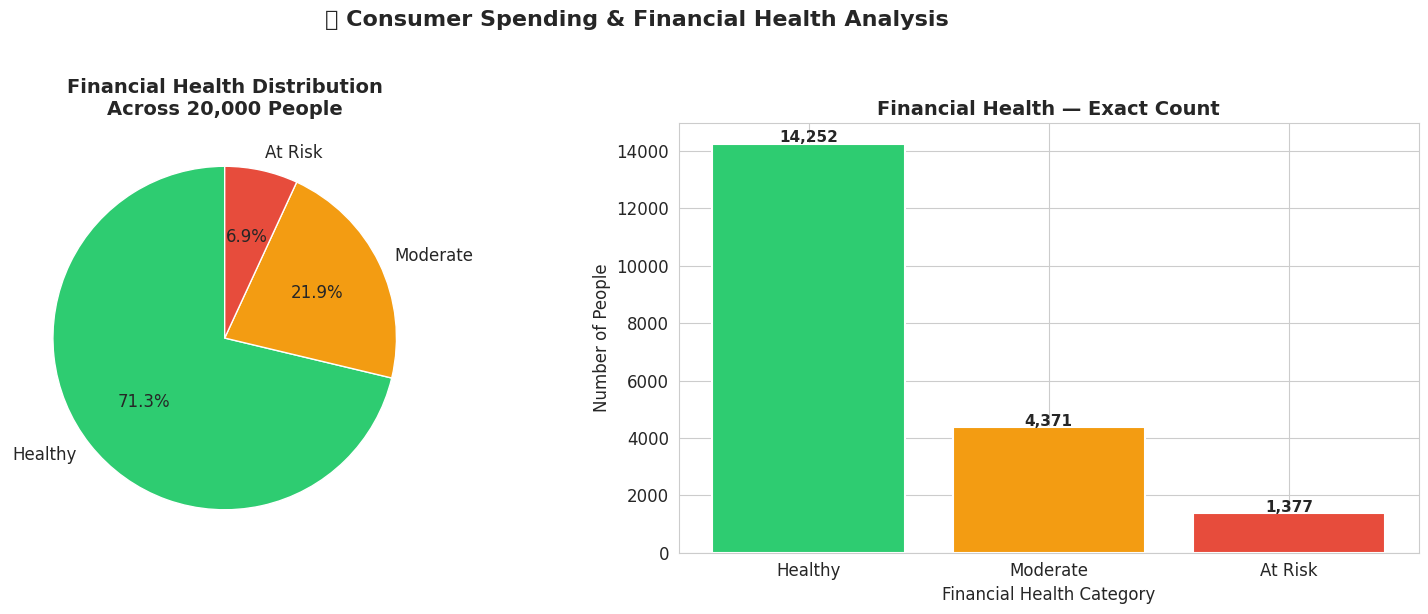

✅ Chart 1 saved!

🔍 KEY INSIGHT:
   14,252 people (71.3%) are Financially Healthy
   1,377 people (6.9%) are At Financial Risk


In [6]:
# ============================================
# STEP 5: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================
# CHART 1 — Financial Health Distribution
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Pie Chart ----
colors = ['#2ecc71', '#f39c12', '#e74c3c']
sizes = df['financial_health'].value_counts()
axes[0].pie(
    sizes,
    labels=sizes.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 12}
)
axes[0].set_title('Financial Health Distribution\nAcross 20,000 People',
                   fontweight='bold', fontsize=14)

# ---- Bar Chart ----
bars = axes[1].bar(
    sizes.index,
    sizes.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5
)
axes[1].set_title('Financial Health — Exact Count',
                   fontweight='bold', fontsize=14)
axes[1].set_xlabel('Financial Health Category')
axes[1].set_ylabel('Number of People')

# Add value labels on bars
for bar, val in zip(bars, sizes.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f'{val:,}',
        ha='center', fontweight='bold', fontsize=11
    )

plt.suptitle('💰 Consumer Spending & Financial Health Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart1_financial_health.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 1 saved!")
print("\n🔍 KEY INSIGHT:")
print(f"   {sizes['Healthy']:,} people ({sizes['Healthy']/len(df)*100:.1f}%) are Financially Healthy")
print(f"   {sizes['At Risk']:,} people ({sizes['At Risk']/len(df)*100:.1f}%) are At Financial Risk")

📊 Age Group Summary:
  age_group  Avg_Income  Avg_Expenses  Avg_Savings
0     18-25    42133.07      31336.89     10796.18
1     26-35    41458.58      30816.07     10642.51
2     36-45    41096.57      30715.54     10381.03
3     46-55    42191.96      31377.51     10814.45
4     56-64    41114.60      30481.59     10633.01


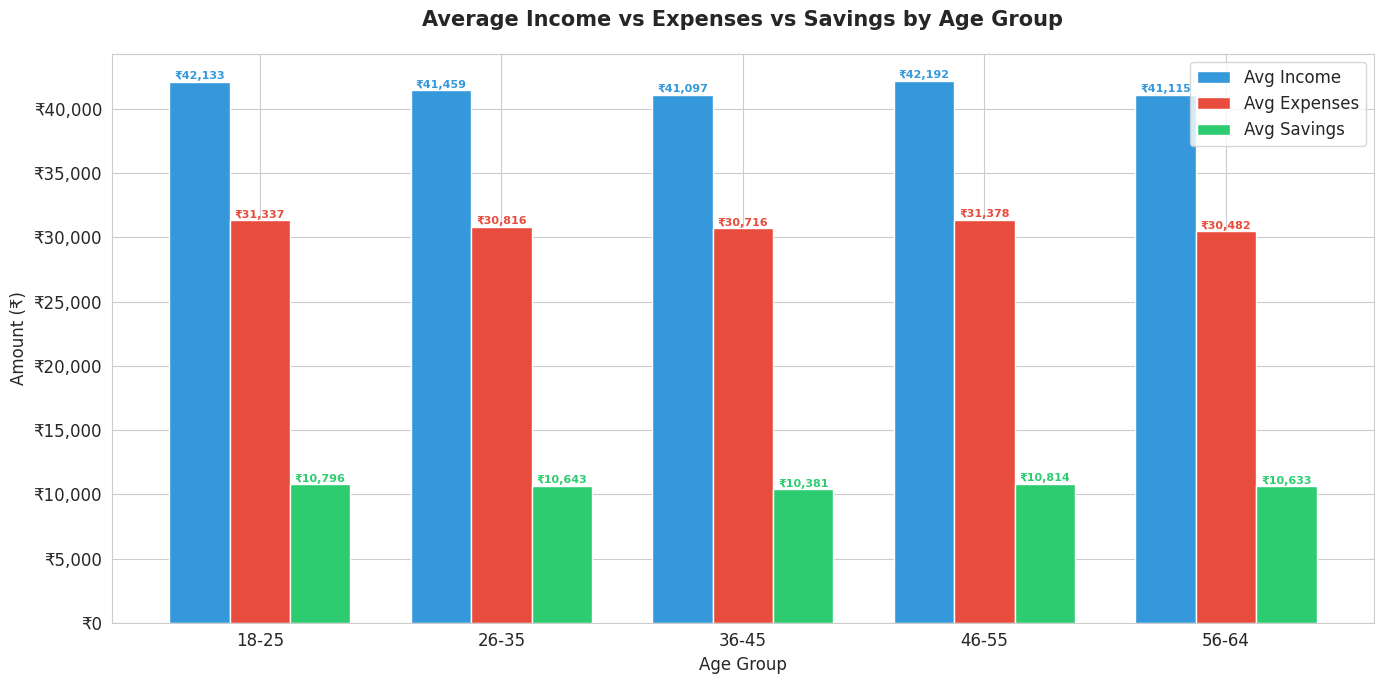


✅ Chart 2 saved!

🔍 KEY INSIGHTS:
   💚 Best saving age group  : 46-55
   ❤️  Worst saving age group : 36-45
   💰 Highest income age group: 46-55


In [7]:
# ============================================
# CHART 2 — INCOME vs EXPENSES vs SAVINGS
#            BY AGE GROUP
# ============================================

age_summary = df.groupby('age_group', observed=True).agg(
    Avg_Income    = ('income', 'mean'),
    Avg_Expenses  = ('total_expenses', 'mean'),
    Avg_Savings   = ('actual_savings', 'mean')
).reset_index()

print("📊 Age Group Summary:")
print(age_summary.round(2))

# ---- Grouped Bar Chart ----
x = range(len(age_summary))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))

bars1 = ax.bar([i - width for i in x],
                age_summary['Avg_Income'],
                width, label='Avg Income',
                color='#3498db', edgecolor='white')

bars2 = ax.bar(x,
                age_summary['Avg_Expenses'],
                width, label='Avg Expenses',
                color='#e74c3c', edgecolor='white')

bars3 = ax.bar([i + width for i in x],
                age_summary['Avg_Savings'],
                width, label='Avg Savings',
                color='#2ecc71', edgecolor='white')

# ---- Labels on bars ----
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'₹{bar.get_height():,.0f}',
            ha='center', fontsize=8, fontweight='bold', color='#3498db')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'₹{bar.get_height():,.0f}',
            ha='center', fontsize=8, fontweight='bold', color='#e74c3c')

for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'₹{bar.get_height():,.0f}',
            ha='center', fontsize=8, fontweight='bold', color='#2ecc71')

ax.set_xticks(list(x))
ax.set_xticklabels(age_summary['age_group'], fontsize=12)
ax.set_title('Average Income vs Expenses vs Savings by Age Group',
             fontweight='bold', fontsize=15, pad=20)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Amount (₹)', fontsize=12)
ax.legend(fontsize=12)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}')
)

plt.tight_layout()
plt.savefig('chart2_income_expenses_savings_age.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Chart 2 saved!")
print("\n🔍 KEY INSIGHTS:")

best_saving_age = age_summary.loc[age_summary['Avg_Savings'].idxmax(), 'age_group']
worst_saving_age = age_summary.loc[age_summary['Avg_Savings'].idxmin(), 'age_group']
best_income_age = age_summary.loc[age_summary['Avg_Income'].idxmax(), 'age_group']

print(f"   💚 Best saving age group  : {best_saving_age}")
print(f"   ❤️  Worst saving age group : {worst_saving_age}")
print(f"   💰 Highest income age group: {best_income_age}")

📊 Average Spending Per Category:
rent              9115.49
groceries         5205.67
transport         2704.47
utilities         2504.98
education         2498.35
loan_repayment    2049.80
healthcare        1663.08
eating_out        1461.86
insurance         1455.03
entertainment     1448.85
miscellaneous      830.55
dtype: float64

📊 Percentage of Total Spending:
rent              29.5
groceries         16.8
transport          8.7
utilities          8.1
education          8.1
loan_repayment     6.6
healthcare         5.4
eating_out         4.7
insurance          4.7
entertainment      4.7
miscellaneous      2.7
dtype: float64


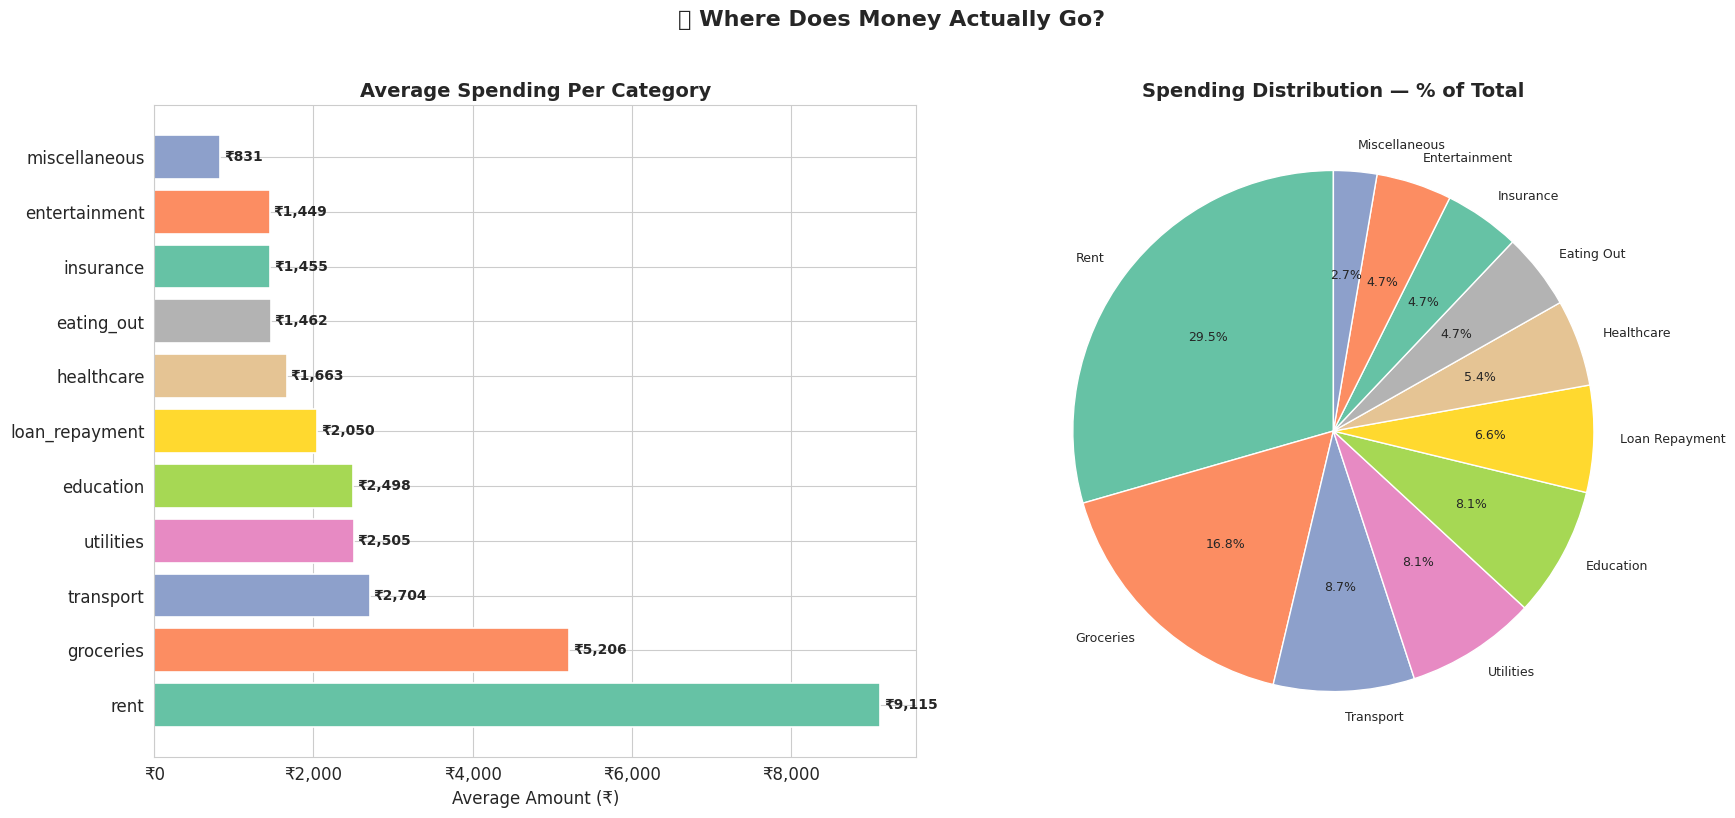


✅ Chart 3 saved!

🔍 KEY INSIGHTS:
   💸 Biggest expense category  : Rent
   💸 Second biggest expense    : Groceries
   💚 Lowest expense category   : Miscellaneous
   📊 Rent takes up             : 29.5% of all spending
   📊 Groceries takes up        : 16.8% of all spending


In [8]:
# ============================================
# CHART 3 — SPENDING CATEGORY BREAKDOWN
#            WHERE DOES MONEY GO?
# ============================================

# ---- Calculate average spending per category ----
expense_categories = [
    'rent', 'loan_repayment', 'insurance', 'groceries',
    'transport', 'eating_out', 'entertainment',
    'utilities', 'healthcare', 'education', 'miscellaneous'
]

avg_spending = df[expense_categories].mean().sort_values(ascending=False)

print("📊 Average Spending Per Category:")
print(avg_spending.round(2))

# ---- Calculate percentage of total ----
total_avg = avg_spending.sum()
spending_pct = (avg_spending / total_avg * 100).round(1)

print("\n📊 Percentage of Total Spending:")
print(spending_pct)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ---- Bar Chart ----
colors = sns.color_palette("Set2", len(avg_spending))
bars = axes[0].barh(
    avg_spending.index,
    avg_spending.values,
    color=colors,
    edgecolor='white',
    linewidth=1.2
)

# Add value labels
for bar, val in zip(bars, avg_spending.values):
    axes[0].text(
        bar.get_width() + 50,
        bar.get_y() + bar.get_height()/2,
        f'₹{val:,.0f}',
        va='center', fontsize=10, fontweight='bold'
    )

axes[0].set_title('Average Spending Per Category',
                   fontweight='bold', fontsize=14)
axes[0].set_xlabel('Average Amount (₹)', fontsize=12)
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}')
)

# ---- Pie Chart ----
axes[1].pie(
    avg_spending.values,
    labels=[cat.replace('_', ' ').title() for cat in avg_spending.index],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 9}
)
axes[1].set_title('Spending Distribution — % of Total',
                   fontweight='bold', fontsize=14)

plt.suptitle('💸 Where Does Money Actually Go?',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart3_spending_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Chart 3 saved!")
print("\n🔍 KEY INSIGHTS:")
top_expense = avg_spending.index[0]
second_expense = avg_spending.index[1]
lowest_expense = avg_spending.index[-1]
print(f"   💸 Biggest expense category  : {top_expense.replace('_',' ').title()}")
print(f"   💸 Second biggest expense    : {second_expense.replace('_',' ').title()}")
print(f"   💚 Lowest expense category   : {lowest_expense.replace('_',' ').title()}")
print(f"   📊 Rent takes up             : {spending_pct['rent']:.1f}% of all spending")
print(f"   📊 Groceries takes up        : {spending_pct['groceries']:.1f}% of all spending")

📊 Income Group Summary:
  income_group  Avg_Income  Avg_Savings  Avg_Expenses  Avg_Savings_Rate  \
0     Very Low    12988.73      3312.14       9676.59             25.47   
1          Low    29016.24      7354.22      21662.02             25.33   
2       Medium    52408.13     13436.82      38971.31             25.67   
3         High   103156.95     26669.06      76487.89             25.82   
4    Very High   274155.38     69103.46     205051.92             25.16   

   People_Count  
0          6124  
1          6683  
2          4251  
3          2755  
4           187  


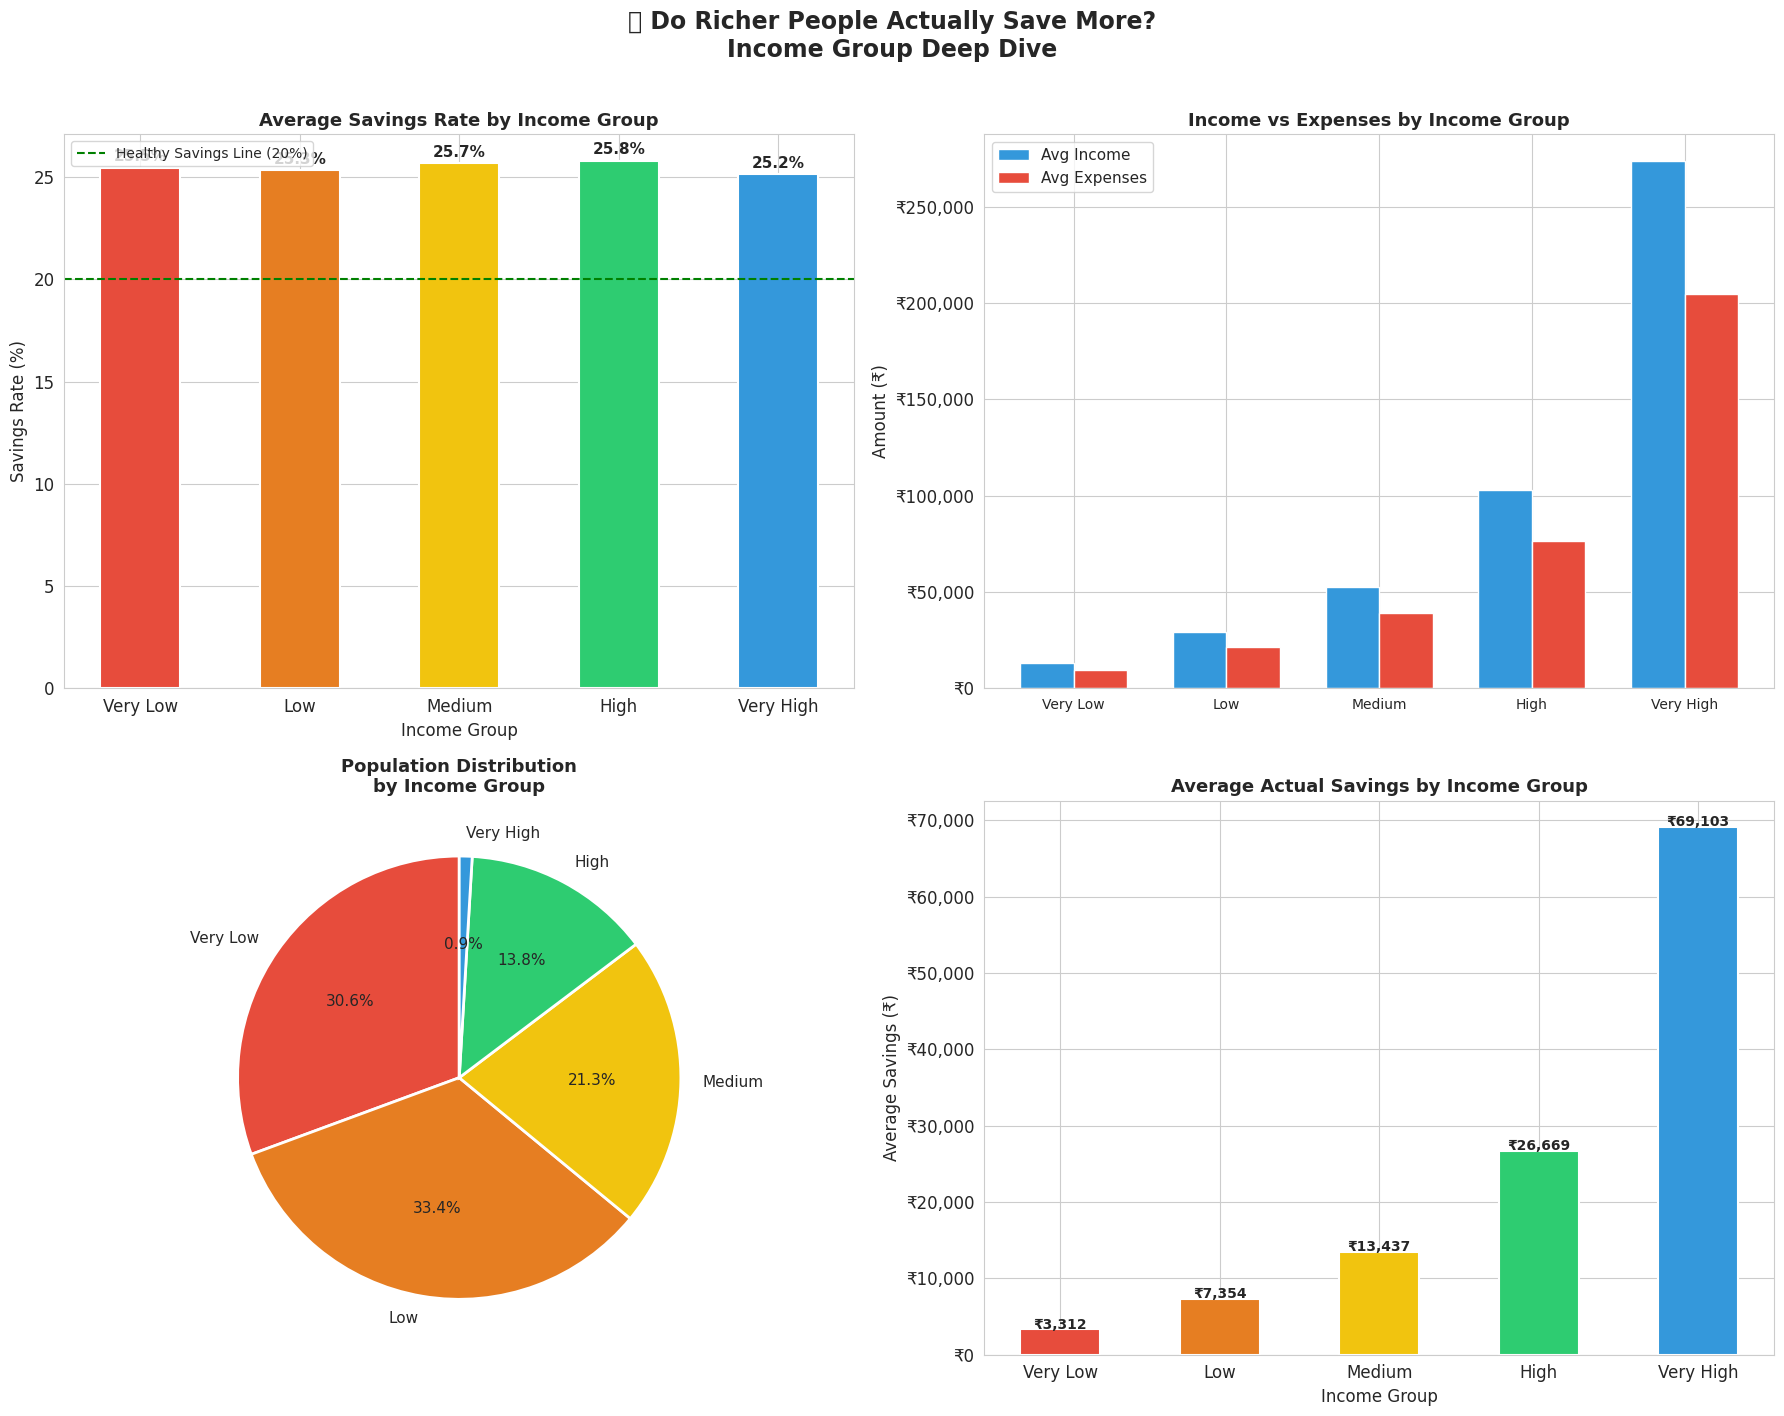

✅ Chart 4 saved!

🔍 KEY INSIGHTS:
   💚 Highest savings rate group : High
   ❤️  Lowest savings rate group  : Very High
   📊 Very Low     → Saves ₹     3,312 | Rate:   25.5%
   📊 Low          → Saves ₹     7,354 | Rate:   25.3%
   📊 Medium       → Saves ₹    13,437 | Rate:   25.7%
   📊 High         → Saves ₹    26,669 | Rate:   25.8%
   📊 Very High    → Saves ₹    69,103 | Rate:   25.2%


In [9]:
# ============================================
# CHART 4 — INCOME GROUP vs SAVINGS RATE
#            DO RICHER PEOPLE SAVE MORE?
# ============================================

income_summary = df.groupby('income_group', observed=True).agg(
    Avg_Income      = ('income', 'mean'),
    Avg_Savings     = ('actual_savings', 'mean'),
    Avg_Expenses    = ('total_expenses', 'mean'),
    Avg_Savings_Rate= ('savings_rate', 'mean'),
    People_Count    = ('income', 'count')
).reset_index()

print("📊 Income Group Summary:")
print(income_summary.round(2))

# ---- Define consistent colors ----
income_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']
income_order  = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
income_summary['income_group'] = pd.Categorical(
    income_summary['income_group'], categories=income_order, ordered=True
)
income_summary = income_summary.sort_values('income_group')

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('💰 Do Richer People Actually Save More?\nIncome Group Deep Dive',
             fontsize=17, fontweight='bold', y=1.01)

# ---- Plot 1: Avg Savings Rate by Income Group ----
bars = axes[0, 0].bar(
    income_summary['income_group'],
    income_summary['Avg_Savings_Rate'],
    color=income_colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
for bar, val in zip(bars, income_summary['Avg_Savings_Rate']):
    axes[0, 0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', fontweight='bold', fontsize=11
    )
axes[0, 0].set_title('Average Savings Rate by Income Group',
                      fontweight='bold', fontsize=13)
axes[0, 0].set_xlabel('Income Group')
axes[0, 0].set_ylabel('Savings Rate (%)')
axes[0, 0].axhline(y=20, color='green', linestyle='--',
                    linewidth=1.5, label='Healthy Savings Line (20%)')
axes[0, 0].legend(fontsize=10)

# ---- Plot 2: Avg Income vs Avg Expenses ----
x      = range(len(income_summary))
width  = 0.35
bars1  = axes[0, 1].bar(
    [i - width/2 for i in x],
    income_summary['Avg_Income'],
    width, color='#3498db',
    label='Avg Income', edgecolor='white'
)
bars2  = axes[0, 1].bar(
    [i + width/2 for i in x],
    income_summary['Avg_Expenses'],
    width, color='#e74c3c',
    label='Avg Expenses', edgecolor='white'
)
axes[0, 1].set_xticks(list(x))
axes[0, 1].set_xticklabels(income_summary['income_group'], fontsize=10)
axes[0, 1].set_title('Income vs Expenses by Income Group',
                      fontweight='bold', fontsize=13)
axes[0, 1].set_ylabel('Amount (₹)')
axes[0, 1].legend(fontsize=11)
axes[0, 1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}')
)

# ---- Plot 3: People Count per Income Group ----
axes[1, 0].pie(
    income_summary['People_Count'],
    labels=income_summary['income_group'],
    autopct='%1.1f%%',
    colors=income_colors,
    startangle=90,
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1, 0].set_title('Population Distribution\nby Income Group',
                      fontweight='bold', fontsize=13)

# ---- Plot 4: Avg Actual Savings by Income Group ----
bars3 = axes[1, 1].bar(
    income_summary['income_group'],
    income_summary['Avg_Savings'],
    color=income_colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
for bar, val in zip(bars3, income_summary['Avg_Savings']):
    axes[1, 1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 100,
        f'₹{val:,.0f}',
        ha='center', fontweight='bold', fontsize=10
    )
axes[1, 1].set_title('Average Actual Savings by Income Group',
                      fontweight='bold', fontsize=13)
axes[1, 1].set_xlabel('Income Group')
axes[1, 1].set_ylabel('Average Savings (₹)')
axes[1, 1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}')
)

plt.tight_layout()
plt.savefig('chart4_income_vs_savings.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 4 saved!")
print("\n🔍 KEY INSIGHTS:")
best_saver  = income_summary.loc[income_summary['Avg_Savings_Rate'].idxmax(), 'income_group']
worst_saver = income_summary.loc[income_summary['Avg_Savings_Rate'].idxmin(), 'income_group']
print(f"   💚 Highest savings rate group : {best_saver}")
print(f"   ❤️  Lowest savings rate group  : {worst_saver}")

for _, row in income_summary.iterrows():
    gap = row['Avg_Income'] - row['Avg_Expenses']
    print(f"   📊 {row['income_group']:<12} → "
          f"Saves ₹{row['Avg_Savings']:>10,.0f} "
          f"| Rate: {row['Avg_Savings_Rate']:>6.1f}%")

📊 Occupation Summary:
      occupation  Avg_Income  Avg_Savings_Rate  Avg_Expenses  Avg_Savings  \
0   Professional    42020.47             25.54      31232.29     10788.19   
3        Student    41829.58             25.58      31089.84     10739.75   
2  Self_Employed    41829.16             25.52      31185.28     10643.88   
1        Retired    40666.77             25.41      30248.63     10418.14   

   People_Count  
0          5011  
3          5003  
2          4967  
1          5019  

📊 Financial Health % by Occupation:
financial_health  At Risk  Healthy  Moderate
occupation                                  
Professional          6.8     71.4      21.7
Retired               7.1     70.4      22.5
Self_Employed         6.9     71.1      22.1
Student               6.7     72.1      21.1


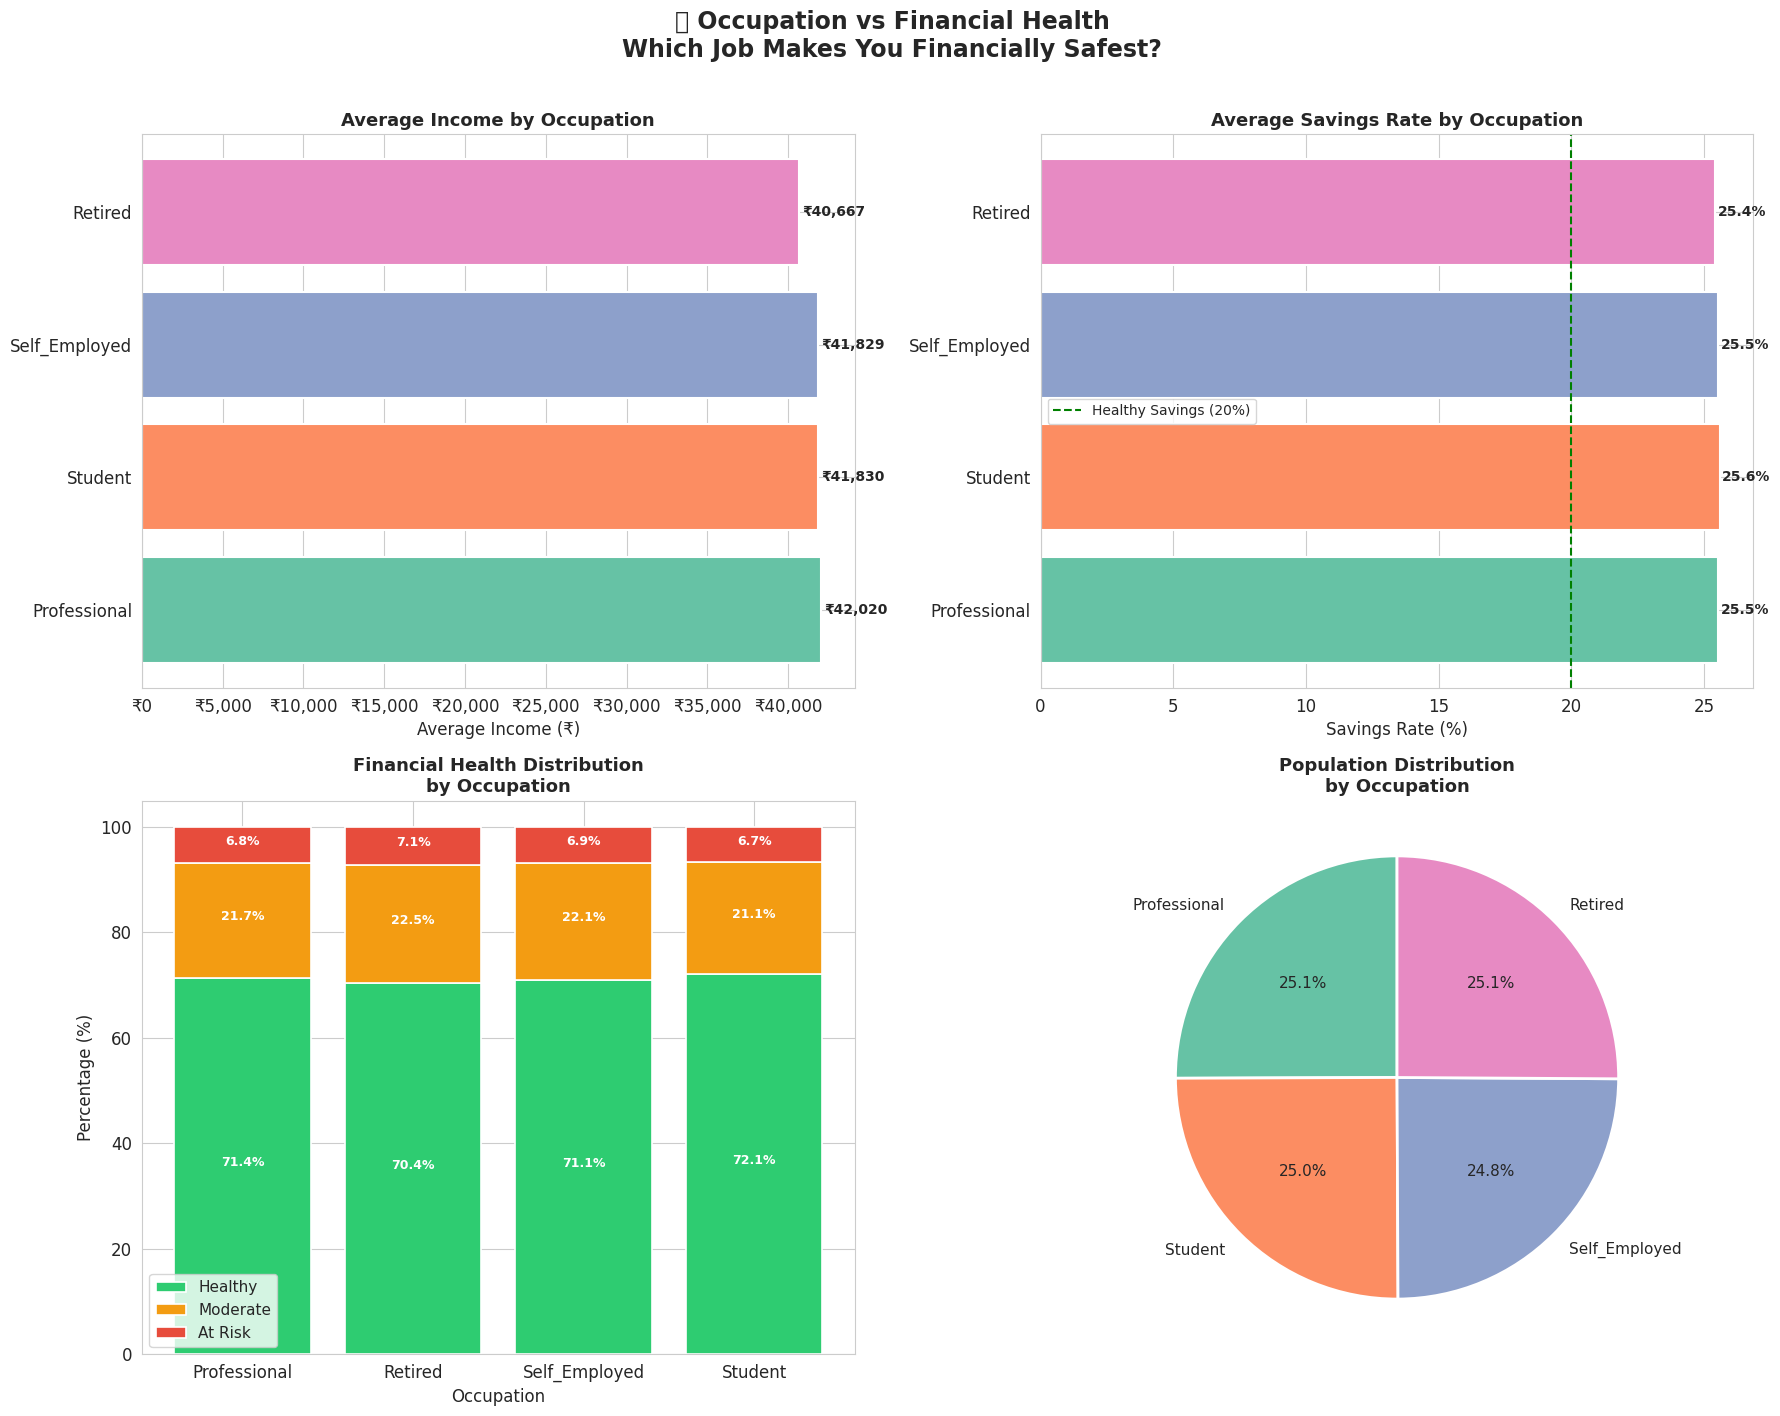

✅ Chart 5 saved!

🔍 KEY INSIGHTS:
   💰 Highest income occupation  : Professional
   📉 Lowest income occupation   : Retired
   💚 Best savings rate occupation: Student

   📊 Occupation breakdown:
   Professional         → Avg Income: ₹    42,020 | Savings Rate: 25.5%
   Student              → Avg Income: ₹    41,830 | Savings Rate: 25.6%
   Self_Employed        → Avg Income: ₹    41,829 | Savings Rate: 25.5%
   Retired              → Avg Income: ₹    40,667 | Savings Rate: 25.4%


In [10]:
# ============================================
# CHART 5 — OCCUPATION vs FINANCIAL HEALTH
#            WHICH JOB MAKES YOU SAFEST?
# ============================================

# ---- Summary by Occupation ----
occupation_summary = df.groupby('occupation', observed=True).agg(
    Avg_Income       = ('income', 'mean'),
    Avg_Savings_Rate = ('savings_rate', 'mean'),
    Avg_Expenses     = ('total_expenses', 'mean'),
    Avg_Savings      = ('actual_savings', 'mean'),
    People_Count     = ('income', 'count')
).reset_index().sort_values('Avg_Income', ascending=False)

print("📊 Occupation Summary:")
print(occupation_summary.round(2))

# ---- Financial Health by Occupation ----
occ_health = df.groupby(
    ['occupation', 'financial_health'], observed=True
).size().unstack(fill_value=0)

# Convert to percentage
occ_health_pct = occ_health.div(occ_health.sum(axis=1), axis=0) * 100

print("\n📊 Financial Health % by Occupation:")
print(occ_health_pct.round(1))

# ---- Build Charts ----
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('👔 Occupation vs Financial Health\nWhich Job Makes You Financially Safest?',
             fontsize=17, fontweight='bold', y=1.01)

occ_colors = sns.color_palette("Set2", len(occupation_summary))

# ---- Plot 1: Avg Income by Occupation ----
bars = axes[0, 0].barh(
    occupation_summary['occupation'],
    occupation_summary['Avg_Income'],
    color=occ_colors,
    edgecolor='white',
    linewidth=1.5
)
for bar, val in zip(bars, occupation_summary['Avg_Income']):
    axes[0, 0].text(
        bar.get_width() + 200,
        bar.get_y() + bar.get_height()/2,
        f'₹{val:,.0f}',
        va='center', fontsize=10, fontweight='bold'
    )
axes[0, 0].set_title('Average Income by Occupation',
                      fontweight='bold', fontsize=13)
axes[0, 0].set_xlabel('Average Income (₹)')
axes[0, 0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}')
)

# ---- Plot 2: Avg Savings Rate by Occupation ----
bars2 = axes[0, 1].barh(
    occupation_summary['occupation'],
    occupation_summary['Avg_Savings_Rate'],
    color=occ_colors,
    edgecolor='white',
    linewidth=1.5
)
for bar, val in zip(bars2, occupation_summary['Avg_Savings_Rate']):
    axes[0, 1].text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height()/2,
        f'{val:.1f}%',
        va='center', fontsize=10, fontweight='bold'
    )
axes[0, 1].set_title('Average Savings Rate by Occupation',
                      fontweight='bold', fontsize=13)
axes[0, 1].set_xlabel('Savings Rate (%)')
axes[0, 1].axvline(x=20, color='green', linestyle='--',
                    linewidth=1.5, label='Healthy Savings (20%)')
axes[0, 1].legend(fontsize=10)

# ---- Plot 3: Stacked Bar — Financial Health % ----
health_colors = {'Healthy': '#2ecc71',
                 'Moderate': '#f39c12',
                 'At Risk': '#e74c3c'}
bottom = np.zeros(len(occ_health_pct))

for health_cat, color in health_colors.items():
    if health_cat in occ_health_pct.columns:
        values = occ_health_pct[health_cat].values
        bars3  = axes[1, 0].bar(
            occ_health_pct.index,
            values,
            bottom=bottom,
            label=health_cat,
            color=color,
            edgecolor='white',
            linewidth=1.2
        )
        for bar, val, bot in zip(bars3, values, bottom):
            if val > 5:
                axes[1, 0].text(
                    bar.get_x() + bar.get_width()/2,
                    bot + val/2,
                    f'{val:.1f}%',
                    ha='center', fontsize=9,
                    fontweight='bold', color='white'
                )
        bottom += values

axes[1, 0].set_title('Financial Health Distribution\nby Occupation',
                      fontweight='bold', fontsize=13)
axes[1, 0].set_xlabel('Occupation')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].legend(fontsize=11)

# ---- Plot 4: People Count by Occupation ----
axes[1, 1].pie(
    occupation_summary['People_Count'],
    labels=occupation_summary['occupation'],
    autopct='%1.1f%%',
    colors=occ_colors,
    startangle=90,
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1, 1].set_title('Population Distribution\nby Occupation',
                      fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('chart5_occupation_financial_health.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 5 saved!")
print("\n🔍 KEY INSIGHTS:")
top_income_occ    = occupation_summary.iloc[0]['occupation']
lowest_income_occ = occupation_summary.iloc[-1]['occupation']
top_saver_occ     = occupation_summary.loc[
    occupation_summary['Avg_Savings_Rate'].idxmax(), 'occupation']

print(f"   💰 Highest income occupation  : {top_income_occ}")
print(f"   📉 Lowest income occupation   : {lowest_income_occ}")
print(f"   💚 Best savings rate occupation: {top_saver_occ}")
print(f"\n   📊 Occupation breakdown:")
for _, row in occupation_summary.iterrows():
    print(f"   {row['occupation']:<20} → "
          f"Avg Income: ₹{row['Avg_Income']:>10,.0f} | "
          f"Savings Rate: {row['Avg_Savings_Rate']:.1f}%")

📊 City Tier Summary:
  city_tier  Avg_Income  Avg_Rent  Avg_Groceries  Avg_Transport  \
2    Tier_3    42031.39   6304.71        5271.08        2733.53   
1    Tier_2    41713.21   8342.64        5214.86        2711.04   
0    Tier_1    41068.39  12320.52        5146.00        2673.73   

   Avg_Eating_Out  Avg_Entertainment  Avg_Savings_Rate  Avg_Expenses  \
2         1484.10            1463.04             32.62      28313.64   
1         1467.44            1457.18             27.45      30227.25   
0         1437.40            1425.17             17.43      33912.49   

   People_Count  
2          3998  
1         10068  
0          5934  


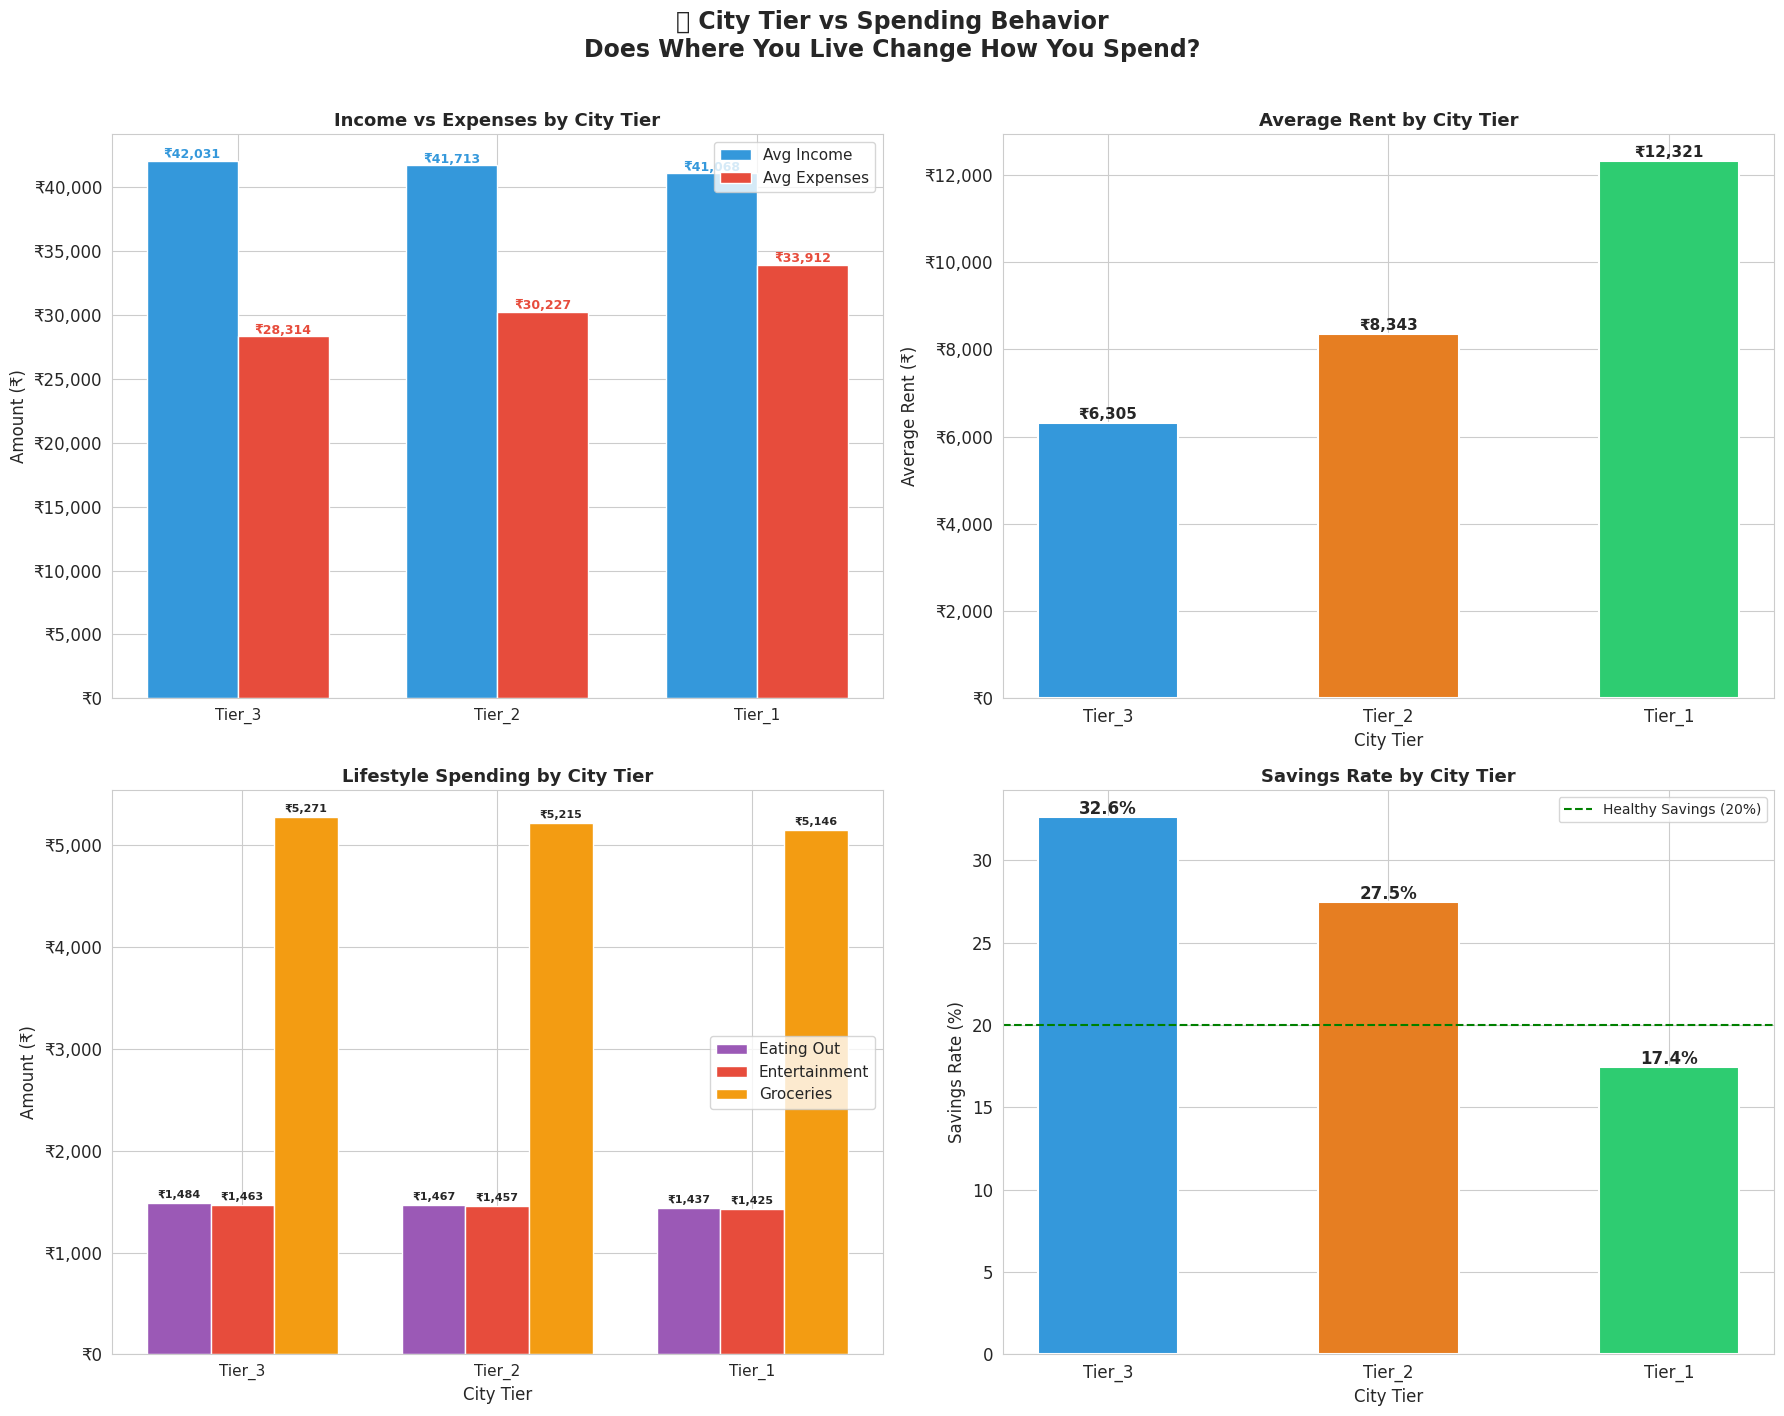

✅ Chart 6 saved!

🔍 KEY INSIGHTS:
   🏠 Highest rent city          : Tier_1
   🏡 Lowest rent city           : Tier_3
   💚 Best savings rate city     : Tier_3

   📊 Full City Tier breakdown:
   Tier_3     → Income: ₹    42,031 | Rent: ₹    6,305 | Savings Rate: 32.6%
   Tier_2     → Income: ₹    41,713 | Rent: ₹    8,343 | Savings Rate: 27.5%
   Tier_1     → Income: ₹    41,068 | Rent: ₹   12,321 | Savings Rate: 17.4%


In [11]:
# ============================================
# CHART 6 — FIXED VERSION
# CITY TIER vs SPENDING BEHAVIOR
# ============================================

city_summary = df.groupby('city_tier', observed=True).agg(
    Avg_Income        = ('income', 'mean'),
    Avg_Rent          = ('rent', 'mean'),
    Avg_Groceries     = ('groceries', 'mean'),
    Avg_Transport     = ('transport', 'mean'),
    Avg_Eating_Out    = ('eating_out', 'mean'),
    Avg_Entertainment = ('entertainment', 'mean'),
    Avg_Savings_Rate  = ('savings_rate', 'mean'),
    Avg_Expenses      = ('total_expenses', 'mean'),
    People_Count      = ('income', 'count')
).reset_index().sort_values('Avg_Income', ascending=False)

print("📊 City Tier Summary:")
print(city_summary.round(2))

# ---- Colors per tier ----
tier_colors = ['#3498db', '#e67e22', '#2ecc71']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('🏙️ City Tier vs Spending Behavior\nDoes Where You Live Change How You Spend?',
             fontsize=17, fontweight='bold', y=1.01)

# ---- Plot 1: Avg Income vs Avg Expenses by City Tier ----
x     = range(len(city_summary))
width = 0.35
bars1 = axes[0, 0].bar(
    [i - width/2 for i in x],
    city_summary['Avg_Income'],
    width, color='#3498db',
    label='Avg Income', edgecolor='white'
)
bars2 = axes[0, 0].bar(
    [i + width/2 for i in x],
    city_summary['Avg_Expenses'],
    width, color='#e74c3c',
    label='Avg Expenses', edgecolor='white'
)
axes[0, 0].set_xticks(list(x))
axes[0, 0].set_xticklabels(city_summary['city_tier'], fontsize=11)
axes[0, 0].set_title('Income vs Expenses by City Tier',
                      fontweight='bold', fontsize=13)
axes[0, 0].set_ylabel('Amount (₹)')
axes[0, 0].legend(fontsize=11)
axes[0, 0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}')
)
for bar in bars1:
    axes[0, 0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f'₹{bar.get_height():,.0f}',
        ha='center', fontsize=9, fontweight='bold', color='#3498db'
    )
for bar in bars2:
    axes[0, 0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f'₹{bar.get_height():,.0f}',
        ha='center', fontsize=9, fontweight='bold', color='#e74c3c'
    )

# ---- Plot 2: Rent Comparison by City Tier ----
bars3 = axes[0, 1].bar(
    city_summary['city_tier'],
    city_summary['Avg_Rent'],
    color=tier_colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
for bar, val in zip(bars3, city_summary['Avg_Rent']):
    axes[0, 1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 100,
        f'₹{val:,.0f}',
        ha='center', fontweight='bold', fontsize=11
    )
axes[0, 1].set_title('Average Rent by City Tier',
                      fontweight='bold', fontsize=13)
axes[0, 1].set_xlabel('City Tier')
axes[0, 1].set_ylabel('Average Rent (₹)')
axes[0, 1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}')
)

# ---- Plot 3: Lifestyle Spending Comparison ----
# Using exact column names from city_summary
lifestyle_cols   = ['Avg_Eating_Out', 'Avg_Entertainment', 'Avg_Groceries']
lifestyle_labels = ['Eating Out',     'Entertainment',     'Groceries']
lifestyle_colors = ['#9b59b6',        '#e74c3c',           '#f39c12']
x2     = range(len(city_summary))
width2 = 0.25

for idx, (col, label, color) in enumerate(
        zip(lifestyle_cols, lifestyle_labels, lifestyle_colors)):
    offset = (idx - 1) * width2
    bars = axes[1, 0].bar(
        [i + offset for i in x2],
        city_summary[col],
        width2,
        label=label,
        color=color,
        edgecolor='white'
    )
    for bar in bars:
        axes[1, 0].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f'₹{bar.get_height():,.0f}',
            ha='center', fontsize=8, fontweight='bold'
        )

axes[1, 0].set_xticks(list(x2))
axes[1, 0].set_xticklabels(city_summary['city_tier'], fontsize=11)
axes[1, 0].set_title('Lifestyle Spending by City Tier',
                      fontweight='bold', fontsize=13)
axes[1, 0].set_xlabel('City Tier')
axes[1, 0].set_ylabel('Amount (₹)')
axes[1, 0].legend(fontsize=11)
axes[1, 0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}')
)

# ---- Plot 4: Savings Rate by City Tier ----
bars4 = axes[1, 1].bar(
    city_summary['city_tier'],
    city_summary['Avg_Savings_Rate'],
    color=tier_colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
for bar, val in zip(bars4, city_summary['Avg_Savings_Rate']):
    axes[1, 1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{val:.1f}%',
        ha='center', fontweight='bold', fontsize=12
    )
axes[1, 1].set_title('Savings Rate by City Tier',
                      fontweight='bold', fontsize=13)
axes[1, 1].set_xlabel('City Tier')
axes[1, 1].set_ylabel('Savings Rate (%)')
axes[1, 1].axhline(y=20, color='green', linestyle='--',
                    linewidth=1.5, label='Healthy Savings (20%)')
axes[1, 1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('chart6_city_tier_spending.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 6 saved!")
print("\n🔍 KEY INSIGHTS:")
highest_rent = city_summary.loc[city_summary['Avg_Rent'].idxmax(), 'city_tier']
lowest_rent  = city_summary.loc[city_summary['Avg_Rent'].idxmin(), 'city_tier']
best_savings = city_summary.loc[city_summary['Avg_Savings_Rate'].idxmax(), 'city_tier']

print(f"   🏠 Highest rent city          : {highest_rent}")
print(f"   🏡 Lowest rent city           : {lowest_rent}")
print(f"   💚 Best savings rate city     : {best_savings}")
print(f"\n   📊 Full City Tier breakdown:")
for _, row in city_summary.iterrows():
    print(f"   {row['city_tier']:<10} → "
          f"Income: ₹{row['Avg_Income']:>10,.0f} | "
          f"Rent: ₹{row['Avg_Rent']:>9,.0f} | "
          f"Savings Rate: {row['Avg_Savings_Rate']:.1f}%")

📊 At Risk People   : 1,377
📊 Moderate People  : 4,371
📊 Healthy People   : 14,252

📊 At Risk Group Profile:
   Avg Income       : ₹40,611
   Avg Expenses     : ₹38,405
   Avg Savings      : ₹2,206
   Avg Savings Rate : 5.5%
   Avg Age          : 41 years

📊 At Risk by Age Group:
age_group
18-25    248
26-35    276
36-45    305
46-55    299
56-64    249
Name: count, dtype: int64

📊 At Risk by City Tier:
city_tier
Tier_1    1193
Tier_2     182
Tier_3       2
Name: count, dtype: int64

📊 At Risk by Occupation:
occupation
Retired          358
Professional     342
Self_Employed    341
Student          336
Name: count, dtype: int64


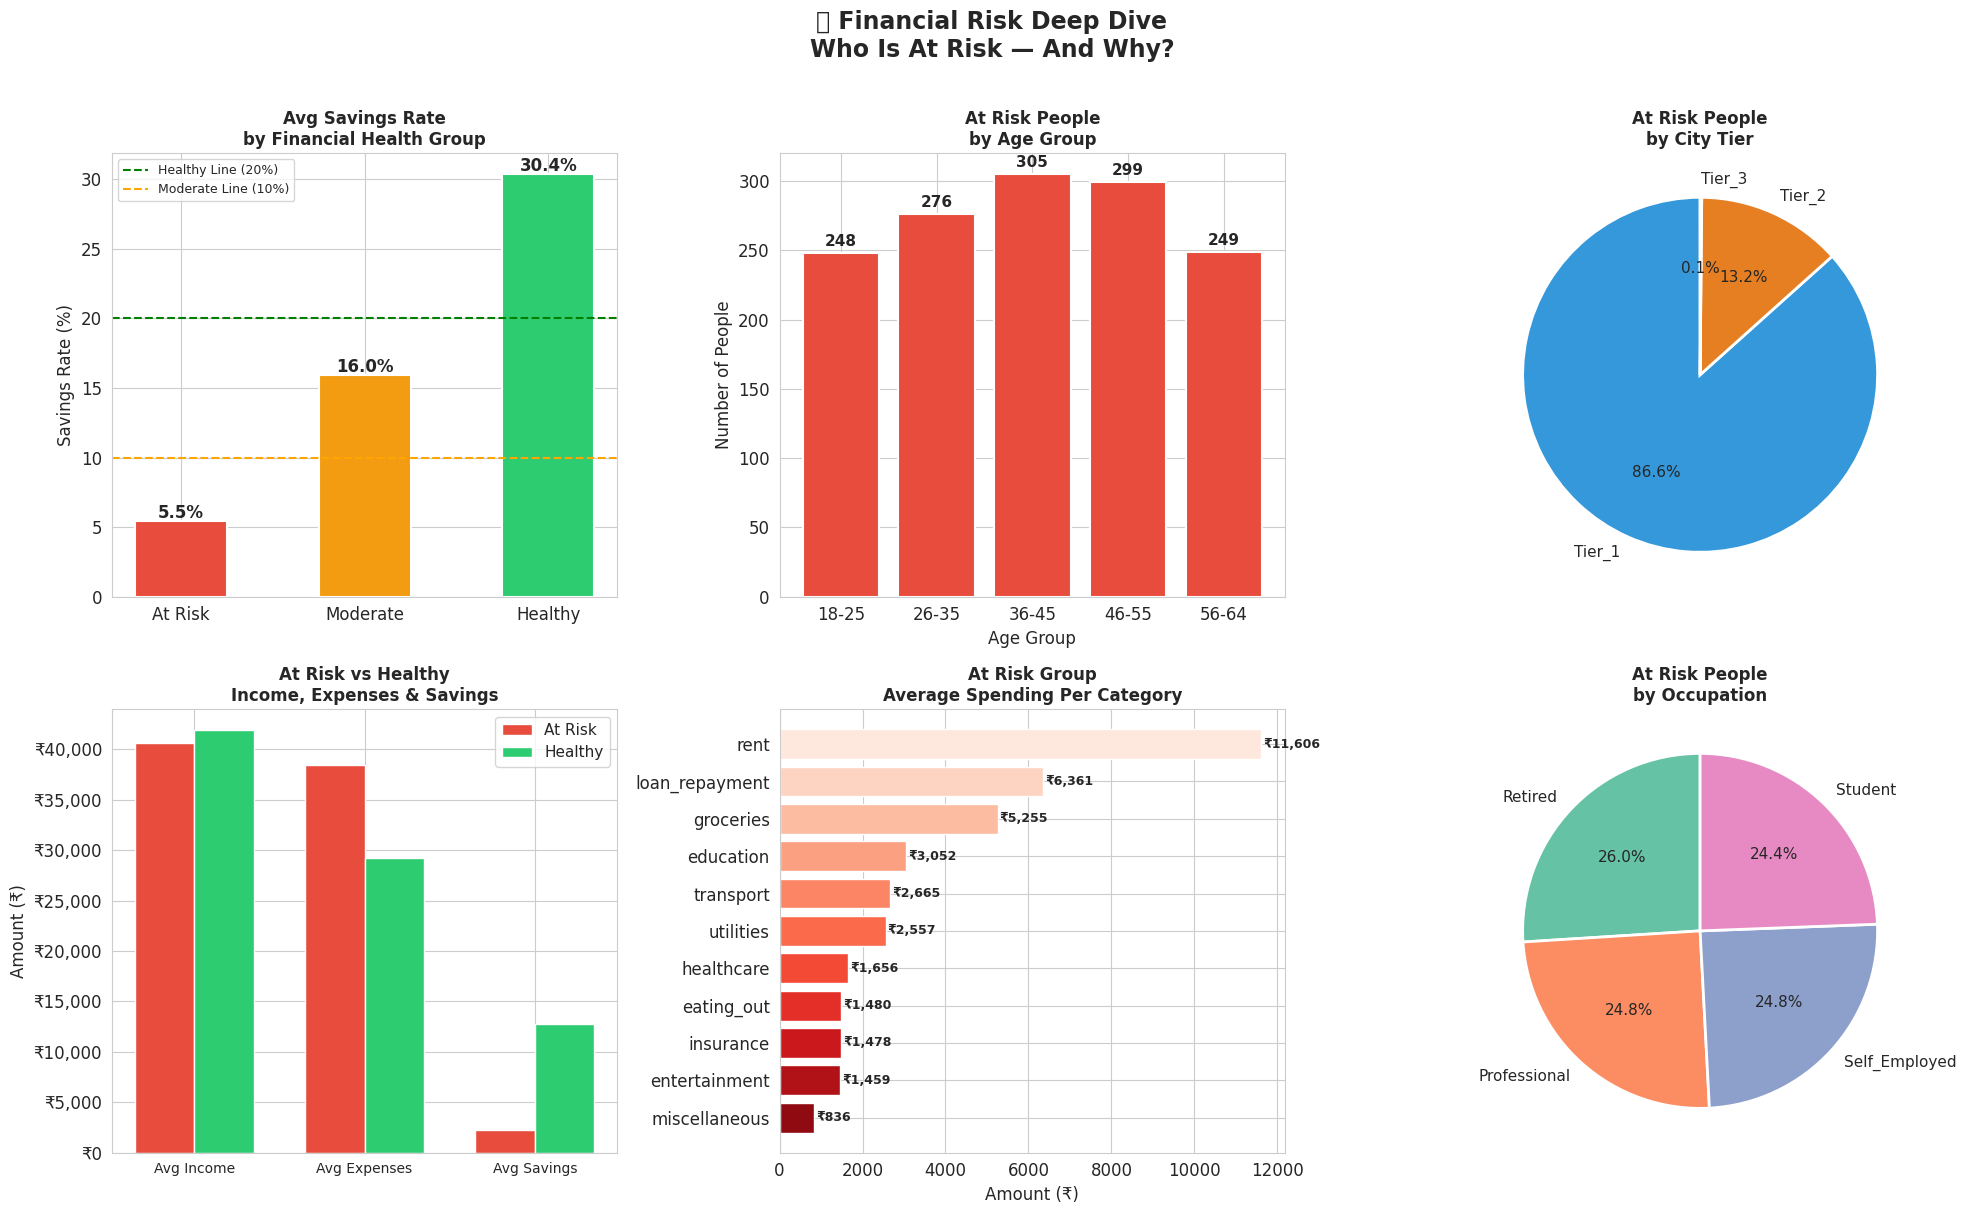


✅ Chart 7 saved!

🔍 KEY INSIGHTS:
   🚨 Most at risk age group  : 36-45
   🏙️  Most at risk city tier  : Tier_1
   👔 Most at risk occupation : Retired
   💸 At Risk avg income      : ₹40,611
   💸 At Risk avg expenses    : ₹38,405
   💚 Healthy avg income      : ₹41,907
   💚 Healthy avg expenses    : ₹29,183


In [12]:
# ============================================
# CHART 7 — FINANCIAL RISK DEEP DIVE
#            WHO IS AT RISK AND WHY?
# ============================================

# ---- Separate At Risk group ----
at_risk    = df[df['financial_health'] == 'At Risk']
healthy    = df[df['financial_health'] == 'Healthy']
moderate   = df[df['financial_health'] == 'Moderate']

print(f"📊 At Risk People   : {len(at_risk):,}")
print(f"📊 Moderate People  : {len(moderate):,}")
print(f"📊 Healthy People   : {len(healthy):,}")

# ---- At Risk profile ----
print("\n📊 At Risk Group Profile:")
print(f"   Avg Income       : ₹{at_risk['income'].mean():,.0f}")
print(f"   Avg Expenses     : ₹{at_risk['total_expenses'].mean():,.0f}")
print(f"   Avg Savings      : ₹{at_risk['actual_savings'].mean():,.0f}")
print(f"   Avg Savings Rate : {at_risk['savings_rate'].mean():.1f}%")
print(f"   Avg Age          : {at_risk['age'].mean():.0f} years")

# ---- Age group distribution in At Risk ----
risk_age   = at_risk['age_group'].value_counts().sort_index()
risk_city  = at_risk['city_tier'].value_counts()
risk_occ   = at_risk['occupation'].value_counts()

print("\n📊 At Risk by Age Group:")
print(risk_age)
print("\n📊 At Risk by City Tier:")
print(risk_city)
print("\n📊 At Risk by Occupation:")
print(risk_occ)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('🚨 Financial Risk Deep Dive\nWho Is At Risk — And Why?',
             fontsize=17, fontweight='bold', y=1.01)

# ---- Plot 1: Savings Rate Comparison across health groups ----
health_groups  = ['At Risk', 'Moderate', 'Healthy']
avg_rates      = [
    at_risk['savings_rate'].mean(),
    moderate['savings_rate'].mean(),
    healthy['savings_rate'].mean()
]
bar_colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = axes[0, 0].bar(
    health_groups, avg_rates,
    color=bar_colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
for bar, val in zip(bars, avg_rates):
    axes[0, 0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{val:.1f}%',
        ha='center', fontweight='bold', fontsize=12
    )
axes[0, 0].set_title('Avg Savings Rate\nby Financial Health Group',
                      fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Savings Rate (%)')
axes[0, 0].axhline(y=20, color='green', linestyle='--',
                    linewidth=1.5, label='Healthy Line (20%)')
axes[0, 0].axhline(y=10, color='orange', linestyle='--',
                    linewidth=1.5, label='Moderate Line (10%)')
axes[0, 0].legend(fontsize=9)

# ---- Plot 2: At Risk by Age Group ----
axes[0, 1].bar(
    risk_age.index,
    risk_age.values,
    color='#e74c3c',
    edgecolor='white',
    linewidth=1.5
)
for i, val in enumerate(risk_age.values):
    axes[0, 1].text(
        i, val + 5,
        str(val),
        ha='center', fontweight='bold', fontsize=11
    )
axes[0, 1].set_title('At Risk People\nby Age Group',
                      fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Age Group')
axes[0, 1].set_ylabel('Number of People')

# ---- Plot 3: At Risk by City Tier ----
axes[0, 2].pie(
    risk_city.values,
    labels=risk_city.index,
    autopct='%1.1f%%',
    colors=['#3498db', '#e67e22', '#2ecc71'],
    startangle=90,
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0, 2].set_title('At Risk People\nby City Tier',
                      fontweight='bold', fontsize=12)

# ---- Plot 4: Income vs Expenses — At Risk vs Healthy ----
categories  = ['Avg Income', 'Avg Expenses', 'Avg Savings']
at_risk_vals= [
    at_risk['income'].mean(),
    at_risk['total_expenses'].mean(),
    at_risk['actual_savings'].mean()
]
healthy_vals= [
    healthy['income'].mean(),
    healthy['total_expenses'].mean(),
    healthy['actual_savings'].mean()
]

x     = range(len(categories))
width = 0.35
axes[1, 0].bar(
    [i - width/2 for i in x],
    at_risk_vals,
    width, color='#e74c3c',
    label='At Risk', edgecolor='white'
)
axes[1, 0].bar(
    [i + width/2 for i in x],
    healthy_vals,
    width, color='#2ecc71',
    label='Healthy', edgecolor='white'
)
axes[1, 0].set_xticks(list(x))
axes[1, 0].set_xticklabels(categories, fontsize=10)
axes[1, 0].set_title('At Risk vs Healthy\nIncome, Expenses & Savings',
                      fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('Amount (₹)')
axes[1, 0].legend(fontsize=11)
axes[1, 0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}')
)

# ---- Plot 5: Top Expenses for At Risk group ----
expense_cols = [
    'rent', 'groceries', 'transport', 'utilities',
    'education', 'loan_repayment', 'healthcare',
    'eating_out', 'insurance', 'entertainment', 'miscellaneous'
]
at_risk_expenses  = at_risk[expense_cols].mean().sort_values(ascending=True)
colors_expenses   = sns.color_palette("Reds_r", len(at_risk_expenses))
axes[1, 1].barh(
    at_risk_expenses.index,
    at_risk_expenses.values,
    color=colors_expenses,
    edgecolor='white'
)
for i, val in enumerate(at_risk_expenses.values):
    axes[1, 1].text(
        val + 50, i,
        f'₹{val:,.0f}',
        va='center', fontsize=9, fontweight='bold'
    )
axes[1, 1].set_title('At Risk Group\nAverage Spending Per Category',
                      fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Amount (₹)')

# ---- Plot 6: At Risk by Occupation ----
axes[1, 2].pie(
    risk_occ.values,
    labels=risk_occ.index,
    autopct='%1.1f%%',
    colors=sns.color_palette("Set2", len(risk_occ)),
    startangle=90,
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1, 2].set_title('At Risk People\nby Occupation',
                      fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('chart7_financial_risk_deepdive.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Chart 7 saved!")
print("\n🔍 KEY INSIGHTS:")
most_at_risk_age  = risk_age.idxmax()
most_at_risk_city = risk_city.idxmax()
most_at_risk_occ  = risk_occ.idxmax()
print(f"   🚨 Most at risk age group  : {most_at_risk_age}")
print(f"   🏙️  Most at risk city tier  : {most_at_risk_city}")
print(f"   👔 Most at risk occupation : {most_at_risk_occ}")
print(f"   💸 At Risk avg income      : ₹{at_risk['income'].mean():,.0f}")
print(f"   💸 At Risk avg expenses    : ₹{at_risk['total_expenses'].mean():,.0f}")
print(f"   💚 Healthy avg income      : ₹{healthy['income'].mean():,.0f}")
print(f"   💚 Healthy avg expenses    : ₹{healthy['total_expenses'].mean():,.0f}")

📊 Average Potential Savings Per Category:
   Groceries            : ₹912
   Transport            : ₹473
   Utilities            : ₹436
   Eating Out           : ₹255
   Entertainment        : ₹254
   Miscellaneous        : ₹145
   Education            : ₹62
   Healthcare           : ₹42

💰 Total Avg Potential Savings Per Person : ₹2,579
💰 Total Potential Savings (20,000 people): ₹51,588,280

📊 Savings Comparison:
   Avg Actual Savings    : ₹10,647
   Avg Desired Savings   : ₹4,983
   Avg Potential Savings : ₹2,579
   Savings Gap           : ₹-5,664


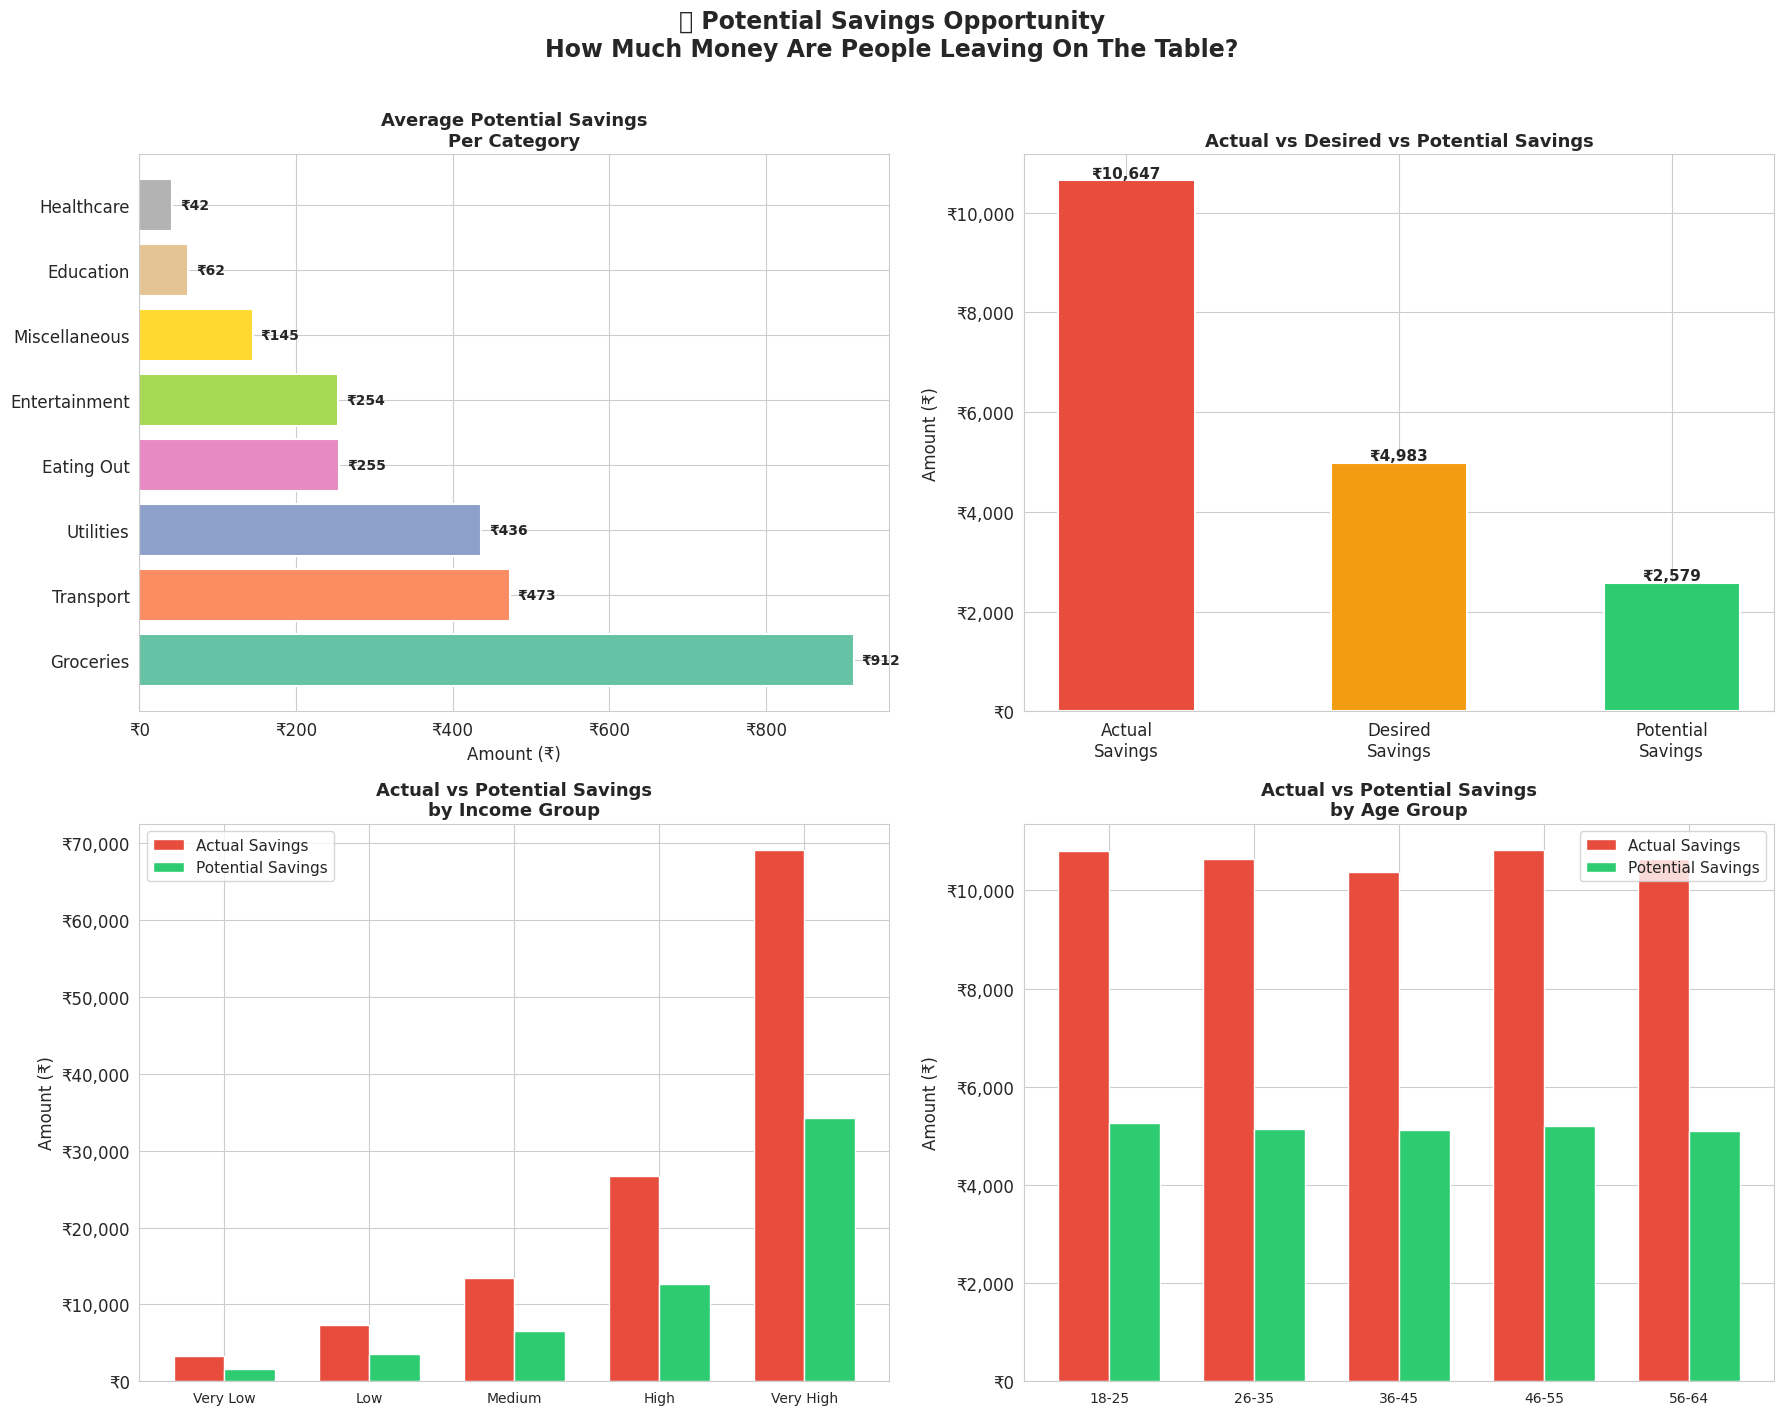


✅ Chart 8 saved!

🔍 KEY INSIGHTS:
   💡 Biggest savings opportunity : Groceries
   💰 Total potential per person  : ₹2,579
   📉 Actual avg savings          : ₹10,647
   🎯 Desired avg savings         : ₹4,983
   📊 Savings gap                 : ₹-5,664

   If all 20,000 people optimized spending:
   💸 Total unlocked savings : ₹51,588,280.27


In [13]:
# ============================================
# CHART 8 — POTENTIAL SAVINGS OPPORTUNITY
#            HOW MUCH ARE PEOPLE LEAVING
#            ON THE TABLE?
# ============================================

potential_cols = [
    'potential_savings_groceries',
    'potential_savings_transport',
    'potential_savings_eating_out',
    'potential_savings_entertainment',
    'potential_savings_utilities',
    'potential_savings_healthcare',
    'potential_savings_education',
    'potential_savings_miscellaneous'
]

avg_potential = df[potential_cols].mean().sort_values(ascending=False)

# Clean labels for display
clean_labels = [
    col.replace('potential_savings_', '').replace('_', ' ').title()
    for col in avg_potential.index
]

print("📊 Average Potential Savings Per Category:")
for label, val in zip(clean_labels, avg_potential.values):
    print(f"   {label:<20} : ₹{val:,.0f}")

total_potential = avg_potential.sum()
print(f"\n💰 Total Avg Potential Savings Per Person : ₹{total_potential:,.0f}")
print(f"💰 Total Potential Savings (20,000 people): ₹{total_potential * 20000:,.0f}")

# ---- Compare Actual vs Potential Savings ----
avg_actual_savings    = df['actual_savings'].mean()
avg_desired_savings   = df['desired_savings'].mean()

print(f"\n📊 Savings Comparison:")
print(f"   Avg Actual Savings    : ₹{avg_actual_savings:,.0f}")
print(f"   Avg Desired Savings   : ₹{avg_desired_savings:,.0f}")
print(f"   Avg Potential Savings : ₹{total_potential:,.0f}")
print(f"   Savings Gap           : ₹{avg_desired_savings - avg_actual_savings:,.0f}")

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('💡 Potential Savings Opportunity\nHow Much Money Are People Leaving On The Table?',
             fontsize=17, fontweight='bold', y=1.01)

# ---- Plot 1: Potential Savings by Category ----
colors = sns.color_palette("Set2", len(avg_potential))
bars = axes[0, 0].barh(
    clean_labels,
    avg_potential.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5
)
for bar, val in zip(bars, avg_potential.values):
    axes[0, 0].text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height()/2,
        f'₹{val:,.0f}',
        va='center', fontsize=10, fontweight='bold'
    )
axes[0, 0].set_title('Average Potential Savings\nPer Category',
                      fontweight='bold', fontsize=13)
axes[0, 0].set_xlabel('Amount (₹)')
axes[0, 0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}')
)

# ---- Plot 2: Actual vs Desired vs Potential Savings ----
comparison_labels = ['Actual\nSavings', 'Desired\nSavings', 'Potential\nSavings']
comparison_values = [avg_actual_savings, avg_desired_savings, total_potential]
comparison_colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars2 = axes[0, 1].bar(
    comparison_labels,
    comparison_values,
    color=comparison_colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
for bar, val in zip(bars2, comparison_values):
    axes[0, 1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f'₹{val:,.0f}',
        ha='center', fontweight='bold', fontsize=11
    )
axes[0, 1].set_title('Actual vs Desired vs Potential Savings',
                      fontweight='bold', fontsize=13)
axes[0, 1].set_ylabel('Amount (₹)')
axes[0, 1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}')
)

# ---- Plot 3: Potential Savings by Income Group ----
income_potential = df.groupby('income_group', observed=True).agg(
    Avg_Potential = ('total_potential_savings', 'mean'),
    Avg_Actual    = ('actual_savings', 'mean')
).reset_index()

income_order = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
income_potential['income_group'] = pd.Categorical(
    income_potential['income_group'],
    categories=income_order, ordered=True
)
income_potential = income_potential.sort_values('income_group')

x     = range(len(income_potential))
width = 0.35
axes[1, 0].bar(
    [i - width/2 for i in x],
    income_potential['Avg_Actual'],
    width, color='#e74c3c',
    label='Actual Savings', edgecolor='white'
)
axes[1, 0].bar(
    [i + width/2 for i in x],
    income_potential['Avg_Potential'],
    width, color='#2ecc71',
    label='Potential Savings', edgecolor='white'
)
axes[1, 0].set_xticks(list(x))
axes[1, 0].set_xticklabels(income_potential['income_group'], fontsize=10)
axes[1, 0].set_title('Actual vs Potential Savings\nby Income Group',
                      fontweight='bold', fontsize=13)
axes[1, 0].set_ylabel('Amount (₹)')
axes[1, 0].legend(fontsize=11)
axes[1, 0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}')
)

# ---- Plot 4: Potential Savings by Age Group ----
age_potential = df.groupby('age_group', observed=True).agg(
    Avg_Potential = ('total_potential_savings', 'mean'),
    Avg_Actual    = ('actual_savings', 'mean')
).reset_index()

x2     = range(len(age_potential))
axes[1, 1].bar(
    [i - width/2 for i in x2],
    age_potential['Avg_Actual'],
    width, color='#e74c3c',
    label='Actual Savings', edgecolor='white'
)
axes[1, 1].bar(
    [i + width/2 for i in x2],
    age_potential['Avg_Potential'],
    width, color='#2ecc71',
    label='Potential Savings', edgecolor='white'
)
axes[1, 1].set_xticks(list(x2))
axes[1, 1].set_xticklabels(age_potential['age_group'], fontsize=10)
axes[1, 1].set_title('Actual vs Potential Savings\nby Age Group',
                      fontweight='bold', fontsize=13)
axes[1, 1].set_ylabel('Amount (₹)')
axes[1, 1].legend(fontsize=11)
axes[1, 1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}')
)

plt.tight_layout()
plt.savefig('chart8_potential_savings.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Chart 8 saved!")
print("\n🔍 KEY INSIGHTS:")
top_potential_cat = clean_labels[0]
print(f"   💡 Biggest savings opportunity : {top_potential_cat}")
print(f"   💰 Total potential per person  : ₹{total_potential:,.0f}")
print(f"   📉 Actual avg savings          : ₹{avg_actual_savings:,.0f}")
print(f"   🎯 Desired avg savings         : ₹{avg_desired_savings:,.0f}")
print(f"   📊 Savings gap                 : ₹{avg_desired_savings - avg_actual_savings:,.0f}")
print(f"\n   If all 20,000 people optimized spending:")
print(f"   💸 Total unlocked savings : ₹{total_potential * 20000:,.2f}")

In [14]:
# ============================================
# STEP 7: EXPORT CLEAN DATA FOR SQL
# ============================================

# Export full clean dataset
df.to_csv('finance_clean.csv', index=False)

# Export key summary for Excel dashboard later
age_export    = df.groupby('age_group', observed=True).agg(
    Avg_Income   = ('income', 'mean'),
    Avg_Expenses = ('total_expenses', 'mean'),
    Avg_Savings  = ('actual_savings', 'mean'),
    Count        = ('income', 'count')
).reset_index()

city_export   = df.groupby('city_tier', observed=True).agg(
    Avg_Income       = ('income', 'mean'),
    Avg_Rent         = ('rent', 'mean'),
    Avg_Savings_Rate = ('savings_rate', 'mean'),
    Count            = ('income', 'count')
).reset_index()

health_export = df['financial_health'].value_counts().reset_index()
health_export.columns = ['Financial_Health', 'Count']

age_export.to_csv('summary_age.csv', index=False)
city_export.to_csv('summary_city.csv', index=False)
health_export.to_csv('summary_health.csv', index=False)

# Download all files
from google.colab import files
files.download('finance_clean.csv')
files.download('summary_age.csv')
files.download('summary_city.csv')
files.download('summary_health.csv')

print("✅ All files exported and downloaded!")
print("\n📁 Files ready:")
print("   finance_clean.csv   → for SQL import")
print("   summary_age.csv     → for Excel dashboard")
print("   summary_city.csv    → for Excel dashboard")
print("   summary_health.csv  → for Excel dashboard")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files exported and downloaded!

📁 Files ready:
   finance_clean.csv   → for SQL import
   summary_age.csv     → for Excel dashboard
   summary_city.csv    → for Excel dashboard
   summary_health.csv  → for Excel dashboard
